<a href="https://colab.research.google.com/github/akhilgunti22-dot/assignment-01--bitsom_ba_2511850-/blob/main/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sentence-transformers seaborn matplotlib scikit-learn


In [2]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the final match",
    "The bowler took three wickets in one over",
    "The team won the match by chasing a big target",
    "The captain set an aggressive field placement",

    # Cooking (3)
    "The chef prepared a delicious pasta with fresh ingredients",
    "Baking a cake requires precise measurements and timing",
    "The recipe includes spices and herbs for flavor",

    # Cybersecurity (3)
    "Strong passwords help protect your online accounts",
    "Encryption ensures that data remains secure during transmission",
    "Hackers often exploit vulnerabilities in software systems"
]


In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)
similarity_matrix


array([[ 1.00000036e+00,  5.70684850e-01,  4.49649453e-01,
         1.73958212e-01, -1.91681385e-02,  1.57410130e-01,
        -1.45288538e-02, -4.46328521e-02,  2.77801529e-02,
         7.33909458e-02],
       [ 5.70684850e-01,  1.00000036e+00,  3.80105615e-01,
         1.39128804e-01,  1.11209095e-01,  8.00567344e-02,
         7.09424764e-02,  2.96248086e-02,  2.96674147e-02,
         9.72075015e-02],
       [ 4.49649453e-01,  3.80105615e-01,  1.00000000e+00,
         2.94262946e-01, -1.86772123e-02,  2.96536721e-02,
        -2.61681974e-02, -3.80645767e-02,  7.79027939e-02,
         5.93777522e-02],
       [ 1.73958212e-01,  1.39128804e-01,  2.94262946e-01,
         1.00000012e+00, -2.28795558e-02, -3.13084014e-02,
        -2.86524985e-02,  4.80619483e-02,  3.51157188e-02,
         5.99961951e-02],
       [-1.91681385e-02,  1.11209095e-01, -1.86772123e-02,
        -2.28795558e-02,  1.00000012e+00,  1.38285592e-01,
         4.42364573e-01, -2.73460746e-02,  5.04180565e-02,
         1.

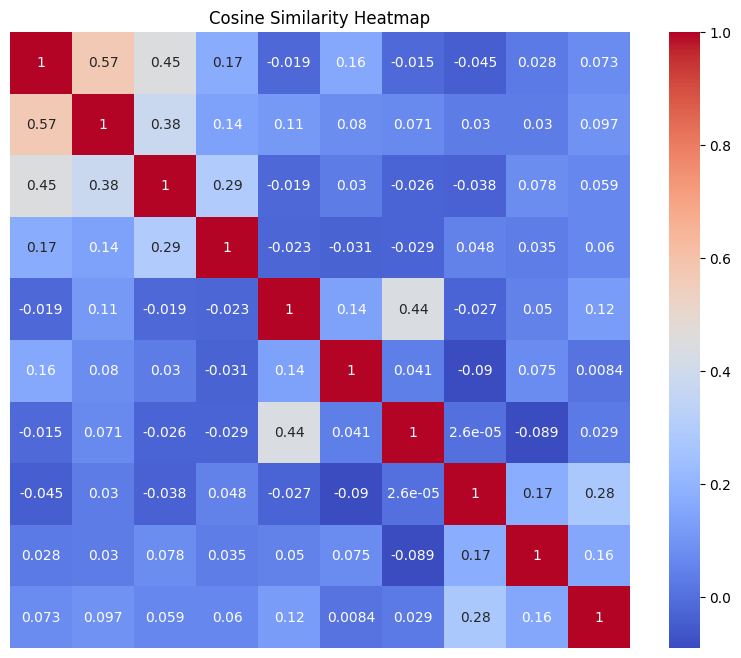

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title("Cosine Similarity Heatmap")
plt.show()

In [6]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 most similar sentences
import numpy as np

top_indices = np.argsort(similarities)[-2:][::-1]

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}")
    print()


Sentence: The bowler took three wickets in one over
Similarity Score: 1.0000

Sentence: The batsman scored a century in the final match
Similarity Score: 0.5707

